
# Actividad 1 — Mejora de imagen: operaciones elementales
### Visión Artificial — Máster Universitario en Inteligencia Artificial (UNIR)
**Autor:** Gabriel Eduardo Morejón López

Este cuaderno implementa y compara tres familias de técnicas de mejora de
imagen —funciones de ajuste de intensidad, procesamiento de histograma y
operadores aritméticos— sobre cuatro imágenes reales del conjunto de datos
**Dark Face** (Yang et al., 2020), seleccionadas siguiendo los criterios de
diversidad descritos en la memoria (Sección 2.2): severidad de la baja
iluminación, tipo de escena, presencia de fuente de luz puntual y ausencia
de desenfoque de movimiento severo.

El código se organiza en un módulo (`pipeline.py`) para mantener el cuaderno
legible; cada celda de código muestra su uso directo. La memoria (documento
PDF/Word que acompaña este cuaderno) describe cada técnica de forma formal
e independiente del lenguaje de programación; aquí se documenta la
implementación concreta empleada.


In [5]:
!pip install opencv-python scikit-image scikit-learn matplotlib numpy pandas seaborn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 45.0 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 56.1 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 82.5 MB/s  0:00:00
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [seaborn]m8/9 [seaborn]mage]


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pipeline import (
    negative, log_transform, gamma_transform, percentile_contrast_stretch,
    histogram_equalization_color, clahe_color,
    linear_adjust, unsharp_mask, illumination_correction_division,
    to_gray, compute_metrics,
)

plt.rcParams["figure.dpi"] = 110



## 0. Carga del conjunto de imágenes

Las cuatro imágenes fueron seleccionadas del conjunto de datos Dark Face
(1080×720 px, color RGB de 24 bits) maximizando la diversidad de severidad
de baja iluminación, tipo de escena y presencia de iluminación puntual, tal
como se justifica en la memoria (Sección 2.2). No se aplica ninguna
degradación simulada: las cuatro imágenes son fotografías reales de baja
iluminación, tal cual se distribuyen en el conjunto de datos original.


In [7]:

rutas = {
    "img1_calle_nocturna":   "images/img1_calle_nocturna.png",
    "img2_callejon_mercado": "images/img2_callejon_mercado.png",
    "img3_plaza_luces":      "images/img3_plaza_luces.png",
    "img4_calle_comercial":  "images/img4_calle_comercial.png",
}

imagenes = {}
for nombre, ruta in rutas.items():
    bgr = cv2.imread(ruta)
    if bgr is None:
        raise FileNotFoundError(ruta)
    imagenes[nombre] = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    print(nombre, imagenes[nombre].shape)


img1_calle_nocturna (720, 1080, 3)
img2_callejon_mercado (720, 1080, 3)
img3_plaza_luces (720, 1080, 3)
img4_calle_comercial (720, 1080, 3)


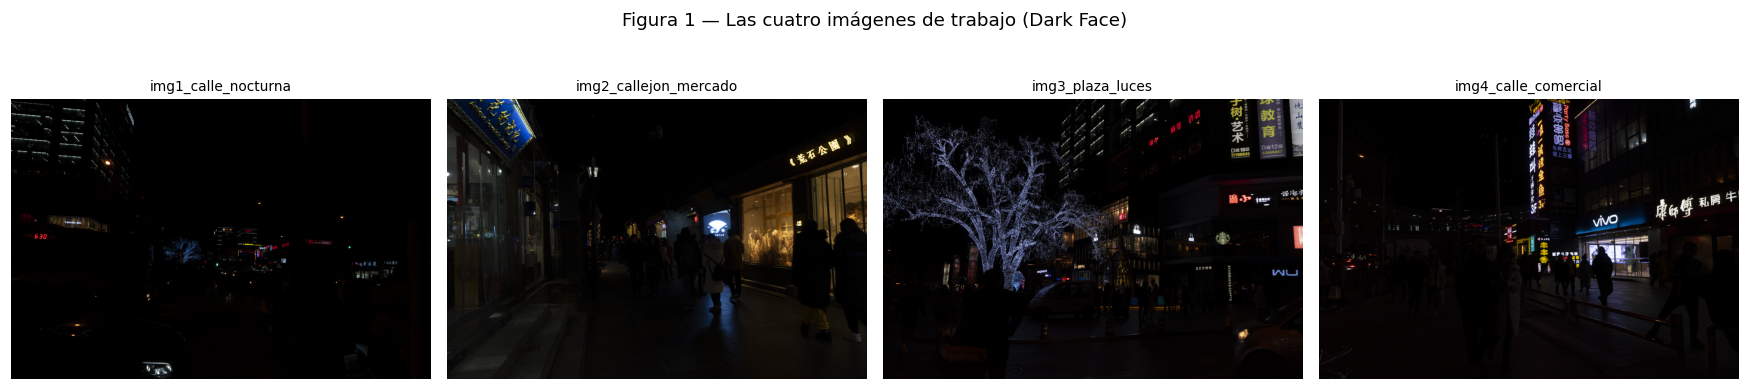

In [8]:

def show_grid(imgs_dict, titulo):
    n = len(imgs_dict)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, (nombre, img) in zip(axes, imgs_dict.items()):
        ax.imshow(img); ax.set_title(nombre, fontsize=9); ax.axis("off")
    fig.suptitle(titulo)
    plt.tight_layout()
    plt.show()


def show_hist_comparison(img_antes, img_despues, nombre):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    axes[0].hist(to_gray(img_antes).ravel(), bins=256, range=(0, 255), color="gray")
    axes[0].set_title(f"{nombre} — histograma antes")
    axes[1].hist(to_gray(img_despues).ravel(), bins=256, range=(0, 255), color="steelblue")
    axes[1].set_title(f"{nombre} — histograma después")
    plt.tight_layout()
    plt.show()


registro_metricas = []

def registrar(tecnica, nombre_img, img):
    fila = {"tecnica": tecnica, "imagen": nombre_img}
    fila.update(compute_metrics(img))
    registro_metricas.append(fila)


for nombre, img in imagenes.items():
    registrar("original", nombre, img)

show_grid(imagenes, "Figura 1 — Las cuatro imágenes de trabajo (Dark Face)")



## 1. Funciones de ajuste de intensidad

Se implementan cuatro funciones puntuales sobre el rango [0, 255]: negativo,
transformación logarítmica, transformación de potencia (gamma = 0.4, para
aclarar selectivamente las zonas oscuras) y estiramiento de contraste por
percentiles (recorte del 2 %/98 % + reescalado lineal).


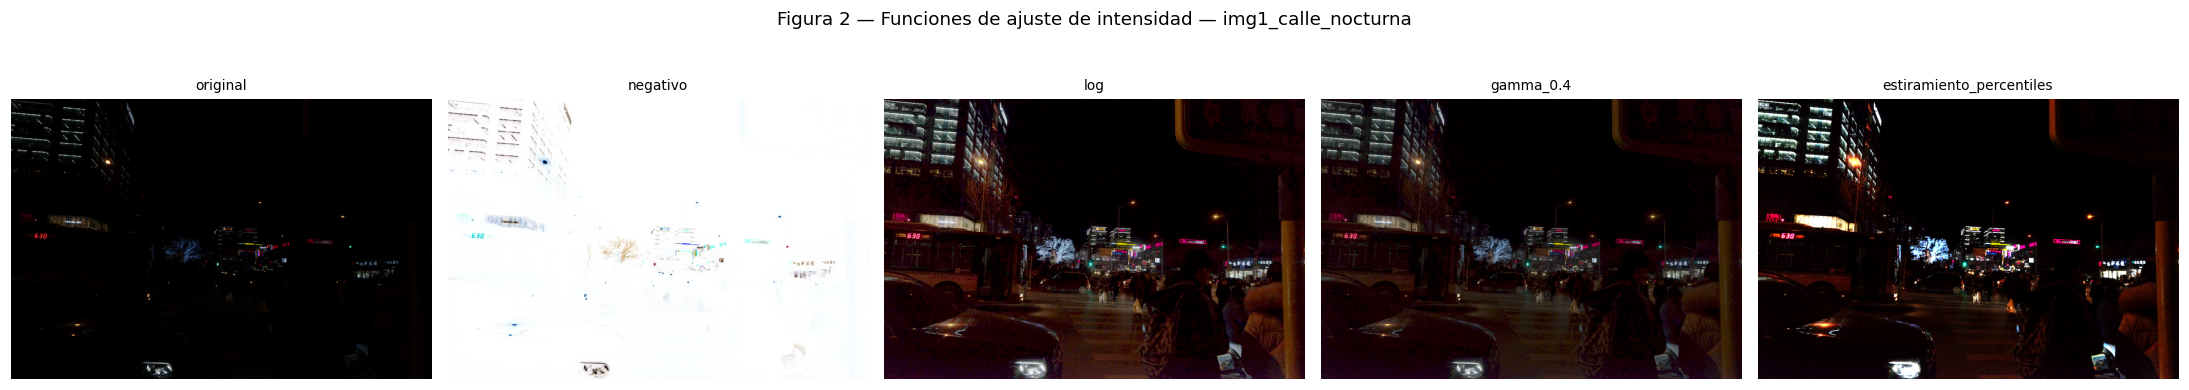

In [9]:

tecnicas_intensidad = {
    "negativo": negative,
    "log": log_transform,
    "gamma_0.4": lambda im: gamma_transform(im, gamma=0.4),
    "estiramiento_percentiles": percentile_contrast_stretch,
}

resultados_intensidad = {}
for nombre_img, img in imagenes.items():
    resultados_intensidad[nombre_img] = {t: f(img) for t, f in tecnicas_intensidad.items()}
    for t, out in resultados_intensidad[nombre_img].items():
        registrar(t, nombre_img, out)

# Vista comparativa sobre la imagen más oscura del conjunto
ejemplo = "img1_calle_nocturna"
grid = {"original": imagenes[ejemplo], **resultados_intensidad[ejemplo]}
show_grid(grid, f"Figura 2 — Funciones de ajuste de intensidad — {ejemplo}")



## 2. Procesamiento de histograma

Ecualización global (HE) y ecualización adaptativa con límite de contraste
(CLAHE, clipLimit=2.0, tiles 8×8). Ambas se aplican sobre el canal de
luminancia Y del espacio YCrCb, y no sobre los canales R, G y B por
separado, para no distorsionar el color de la escena.


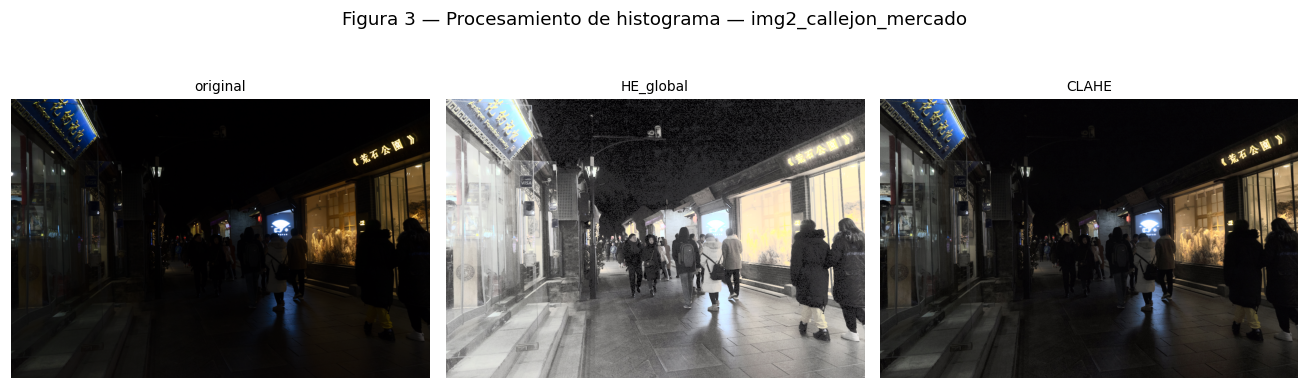

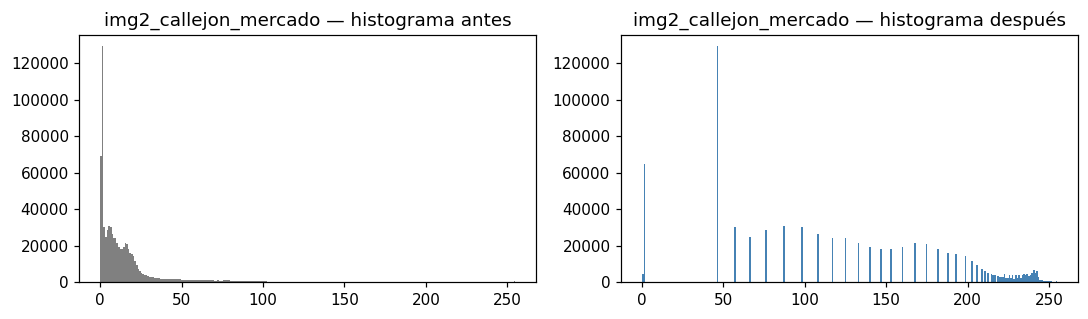

In [5]:

tecnicas_histograma = {
    "HE_global": histogram_equalization_color,
    "CLAHE": clahe_color,
}

resultados_histograma = {}
for nombre_img, img in imagenes.items():
    resultados_histograma[nombre_img] = {t: f(img) for t, f in tecnicas_histograma.items()}
    for t, out in resultados_histograma[nombre_img].items():
        registrar(t, nombre_img, out)

ejemplo = "img2_callejon_mercado"
grid = {"original": imagenes[ejemplo], **resultados_histograma[ejemplo]}
show_grid(grid, f"Figura 3 — Procesamiento de histograma — {ejemplo}")
show_hist_comparison(imagenes[ejemplo], resultados_histograma[ejemplo]["HE_global"], ejemplo)



## 3. Operadores aritméticos

Ajuste lineal de brillo/contraste (`nueva = α·original + β`, α=1.3, β=25),
*unsharp masking* (se resta una versión suavizada de la imagen para aislar
el detalle fino y se vuelve a sumar amplificado, σ=3, amount=1.5) y, como
técnica adicional, corrección de iluminación no homogénea por **división**
entre la imagen y una estimación suavizada de la iluminación (σ=31,
ganancia=128); esta última se calcula sobre la versión en escala de grises.


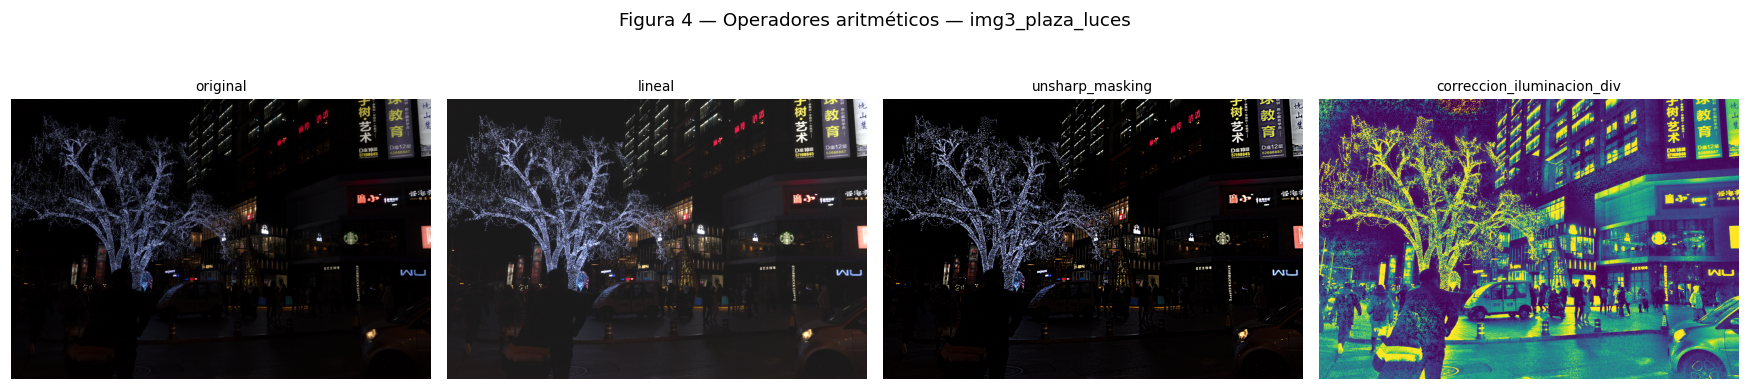

In [6]:

tecnicas_aritmeticas_color = {
    "lineal": linear_adjust,
    "unsharp_masking": unsharp_mask,
}

resultados_aritmeticos = {}
for nombre_img, img in imagenes.items():
    resultados_aritmeticos[nombre_img] = {t: f(img) for t, f in tecnicas_aritmeticas_color.items()}
    gray = to_gray(img)
    resultados_aritmeticos[nombre_img]["correccion_iluminacion_div"] = illumination_correction_division(gray)
    for t, out in resultados_aritmeticos[nombre_img].items():
        registrar(t, nombre_img, out)

ejemplo = "img3_plaza_luces"
grid = {
    "original": imagenes[ejemplo],
    "lineal": resultados_aritmeticos[ejemplo]["lineal"],
    "unsharp_masking": resultados_aritmeticos[ejemplo]["unsharp_masking"],
    "correccion_iluminacion_div": resultados_aritmeticos[ejemplo]["correccion_iluminacion_div"],
}
show_grid(grid, f"Figura 4 — Operadores aritméticos — {ejemplo}")



## 4. Tabla comparativa de métricas

Métricas sin referencia (brillo medio, contraste RMS y entropía de Shannon)
calculadas sobre la versión en escala de grises de cada resultado, para las
cuatro imágenes y las nueve condiciones (original + 8 técnicas).


In [7]:

df = pd.DataFrame(registro_metricas)
df.to_csv("resultados_metricas.csv", index=False)

resumen = df.groupby("tecnica")[["brillo_medio", "contraste_rms", "entropia"]].mean().round(2)
orden = ["original", "negativo", "log", "gamma_0.4", "estiramiento_percentiles",
         "HE_global", "CLAHE", "lineal", "unsharp_masking", "correccion_iluminacion_div"]
resumen = resumen.reindex(orden)
resumen


,brillo_medio,contraste_rms,entropia
tecnica,,,
original,10.86,24.30,4.07
negativo,244.14,24.30,4.07
log,68.10,48.26,5.93
gamma_0.4,47.82,36.74,5.61
estiramiento_percentiles,24.47,46.44,5.08
HE_global,102.72,75.96,4.01
CLAHE,23.32,32.67,4.82
lineal,38.43,28.95,4.25
unsharp_masking,11.57,31.39,3.78


In [8]:

pivot_brillo = df.pivot(index="imagen", columns="tecnica", values="brillo_medio").reindex(columns=orden)
pivot_brillo


tecnica,original,negativo,log,gamma_0.4,estiramiento_percentiles,HE_global,CLAHE,lineal,unsharp_masking,correccion_iluminacion_div
imagen,,,,,,,,,,
img1_calle_nocturna,2.16,252.84,20.27,15.24,15.41,47.95,7.01,27.62,2.57,40.66
img2_callejon_mercado,16.20,238.80,96.96,67.07,37.20,122.02,34.08,45.32,16.14,104.17
img3_plaza_luces,13.90,241.10,78.96,56.14,25.01,122.81,28.39,42.45,16.20,86.64
img4_calle_comercial,11.17,243.83,76.19,52.83,20.26,118.09,23.80,38.34,11.36,94.08



## Declaración de uso de IA

Este cuaderno fue construido con apoyo del asistente de inteligencia
artificial Claude (Anthropic) para estructurar el flujo de trabajo y
redactar los comentarios de las celdas; el autor revisó, ejecutó y verificó
cada celda, y contrastó las cifras resultantes con las discutidas en la
memoria. La declaración completa, con el detalle de tareas y la reflexión
crítica exigidas por la actividad, se encuentra en la memoria (Sección
"Declaración de uso de IA").
